# Water Potability Analysis: Data Cleaning & Preparation

## Project Overview
This project analyzes water quality data to explore factors influencing potability. The dataset contains measurements of pH, hardness, solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, and turbidity — with a target variable indicating whether water is potable (1) or not (0).

## Goals
1. **Identify Key Drivers**: Determine which parameters most influence potability
2. **Segment Water Sources**: Group similar water samples based on quality parameters

## Tools Used
- **Python**: pandas, numpy, matplotlib, seaborn
- **Environment**: Jupyter Notebook
- **Visualization**: Tableau (for dashboard)

## Dataset
- **Source**: Kaggle Water Potability Dataset
- **Rows**: 2620
- **Columns**: 10 (9 features + 1 target)
- **Target**: Potability (1 = potable, 0 = not potable)

## 1. Import Libraries & Load Data

**Purpose**: Load the necessary Python libraries and read the water quality dataset into a DataFrame.

**Key Actions**:
- Import pandas for data manipulation, numpy for numerical operations, and matplotlib/seaborn for visualization
- Load the `water_potability.csv` file
- Perform an initial exploration to understand the dataset structure

**Libraries Used**:
- `pandas` — data manipulation and analysis
- `numpy` — numerical operations
- `matplotlib` / `seaborn` — data visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data.csv')

# Quick overview
print('Dataset shape: ', df.shape)
df.head()

Dataset shape:  (2620, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.150553,212.819377,15017.747281,5.544436,319.494952,279.447066,12.850506,75.028793,4.810537,0
1,NaN,180.680598,8692.538152,8.671793,396.528754,534.339086,10.299787,87.652015,3.913602,0
2,5.344117,198.379144,13492.840835,6.559265,328.648845,591.363369,14.084388,61.392983,4.104699,1
3,7.647872,160.774353,29000.589712,7.217409,NaN,438.800961,13.182501,67.099969,3.078673,1
4,8.129586,177.898967,27834.217696,9.006008,334.438539,397.021428,15.936262,81.390758,3.362537,0


In [3]:
# Check data types and non null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2234 non-null   float64
 1   Hardness         2620 non-null   float64
 2   Solids           2620 non-null   float64
 3   Chloramines      2620 non-null   float64
 4   Sulfate          1999 non-null   float64
 5   Conductivity     2620 non-null   float64
 6   Organic_carbon   2620 non-null   float64
 7   Trihalomethanes  2495 non-null   float64
 8   Turbidity        2620 non-null   float64
 9   Potability       2620 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 204.8 KB


In [4]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

Duplicate rows: 0


## 2. Handle Missing Values

**Purpose**: Identify and address missing values in the dataset to ensure data integrity for analysis.

**Key Actions**:
- Check for missing values across all columns
- Assess the percentage of missing data per column
- Drop rows with missing values to maintain a clean, complete dataset

**Decision**: Rows with missing values were dropped because:
- The dataset contains sufficient rows (2620) to support this approach
- Dropping rows simplifies the dataset for clear analysis and visualization

In [5]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Sulfate,621,23.702290
ph,386,14.732824
Trihalomethanes,125,4.770992


In [6]:
# Drop all rows with missing values into a new dataset
df_clean = df.dropna()

# Check new shape
print(f'Cleaned shape: {df_clean.shape}')
print(f'Rows dropped: {df.shape[0] - df_clean.shape[0]} ({(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.1f}%)')

# Verify that no missing values remain
print(f'Missing values remaining: {df_clean.isnull().sum()}')

df_clean.head()

Cleaned shape: (1617, 10)
Rows dropped: 1003 (38.3%)
Missing values remaining: ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.150553,212.819377,15017.747281,5.544436,319.494952,279.447066,12.850506,75.028793,4.810537,0
2,5.344117,198.379144,13492.840835,6.559265,328.648845,591.363369,14.084388,61.392983,4.104699,1
4,8.129586,177.898967,27834.217696,9.006008,334.438539,397.021428,15.936262,81.390758,3.362537,0
5,8.026773,169.333843,19168.526773,8.081496,405.527337,350.577370,15.177534,68.003932,3.735983,0
6,5.608745,152.954062,19835.980770,9.345981,323.393340,596.076368,14.380725,49.428252,4.644212,0


## 3. Handle Outliers

**Purpose**: Identify and manage extreme values that could skew analysis and visualizations.

**Key Actions**:
- Detect outliers in numeric columns using the Interquartile Range (IQR) method
- Cap extreme values at the 99th percentile to prevent distortion of visualizations

**Decision**: Outliers are a natural part of water quality data, representing extreme natural conditions (e.g., highly mineralized sources). Capping preserves 99% of the data while controlling extreme values that would otherwise stretch charts and skew summary statistics.

**Note**: Outliers are retained but capped to ensure:
- Clear, readable visualizations (boxplots, histograms, scatter plots)
- Representative summary statistics (mean, standard deviation)
- Accurate correlation analysis

In [7]:
# Function to count outliers per column
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

# Check outliers in each numeric column
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != 'Potability':  # Exclude target variable
        outliers = count_outliers(df, col)
        print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

ph: 36 outliers (1.37%)
Hardness: 65 outliers (2.48%)
Solids: 42 outliers (1.60%)
Chloramines: 54 outliers (2.06%)
Sulfate: 30 outliers (1.15%)
Conductivity: 10 outliers (0.38%)
Organic_carbon: 21 outliers (0.80%)
Trihalomethanes: 30 outliers (1.15%)
Turbidity: 14 outliers (0.53%)


In [8]:
# Cap outliers at 99th percentile
for col in numeric_cols:
    if col != 'Potability':
        upper_limit = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper_limit)
        print(f"Capped {col} at {upper_limit:.2f}")

Capped ph at 10.89
Capped Hardness at 277.88
Capped Solids at 45211.94
Capped Chloramines at 11.06
Capped Sulfate at 433.70
Capped Conductivity at 617.47
Capped Organic_carbon at 22.08
Capped Trihalomethanes at 105.17
Capped Turbidity at 5.76


## 4. Correlation Analysis

**Purpose**: Explore relationships between water quality parameters to identify potential drivers of potability.

**Key Actions**:
- Calculate the correlation matrix for all numeric columns
- Visualize correlations using a heatmap
- Export the correlation matrix for use in Tableau

**Business Relevance**: Understanding correlations helps identify which parameters are most closely linked to potability, informing water quality management decisions.

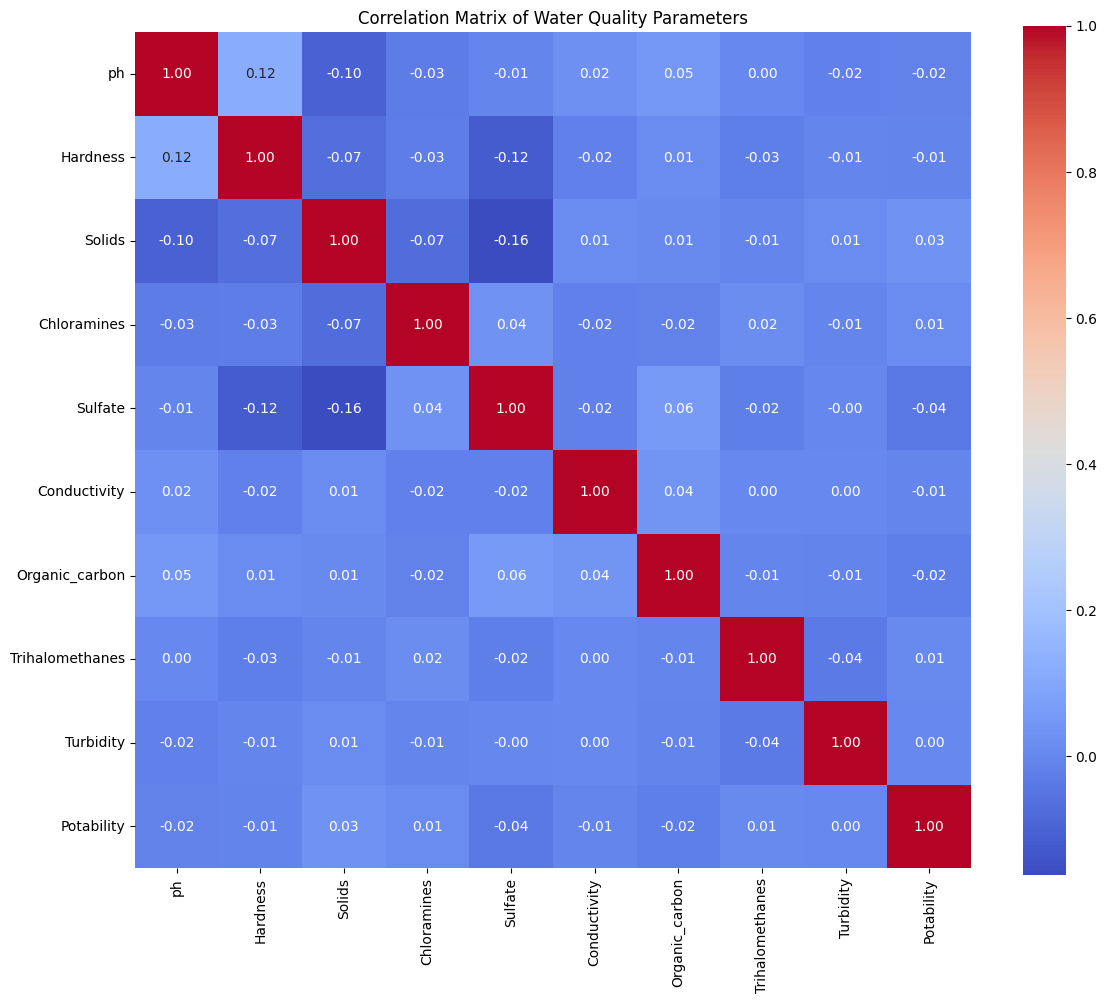

In [9]:
# Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix of Water Quality Parameters')
plt.tight_layout()
plt.show()

# Export correlation matrix for Tableau
corr_matrix.to_csv('correlation_matrix.csv')

## 5. Save Cleaned Data

**Purpose**: Export the cleaned dataset for use in Tableau dashboard creation and Python-based exploratory analysis.

**Key Actions**:
- Verify no missing values remain
- Export to CSV format
- Prepare for Tableau import

**Deliverables**:
- `water_potability_cleaned.csv` — Cleaned dataset ready for analysis and visualization
- Correlation matrix — For use in Tableau (optional)

In [10]:
# Save cleaned dataset
df.to_csv('water_potability_cleaned.csv', index=False)
print("Cleaned dataset saved to 'water_potability_cleaned.csv'")

Cleaned dataset saved to 'water_potability_cleaned.csv'


## 6. Summary Statistics

**Purpose**: Understand the distribution and range of each water quality parameter in the cleaned dataset.

**Interpretation**:
- **pH**: Ranges from 4.3 to 11.3, with a mean of 7.0 (near neutral)
- **Hardness**: Highly variable (47–323), indicating diverse water sources
- **Solids**: Wide range (152–59,622), suggesting different mineral content
- **Potability**: Only ~38% of samples are potable — a significant imbalance worth exploring

In [11]:
# Summary statistics
df_clean.describe()

# Potability breakdown
df_clean['Potability'].value_counts(normalize=True) * 100

Potability
0    59.121831
1    40.878169
Name: proportion, dtype: float64

## 7. Distribution of Water Quality Parameters

**Purpose**: Examine the shape, spread, and central tendency of each parameter using histograms.

**Key Observations**:
- **pH**: Approximately normal distribution centered around 7.0
- **Hardness**: Slightly right-skewed
- **Solids**: Highly right-skewed, with many low values and a few very high values
- **Potability**: Imbalanced — more non-potable samples than potable

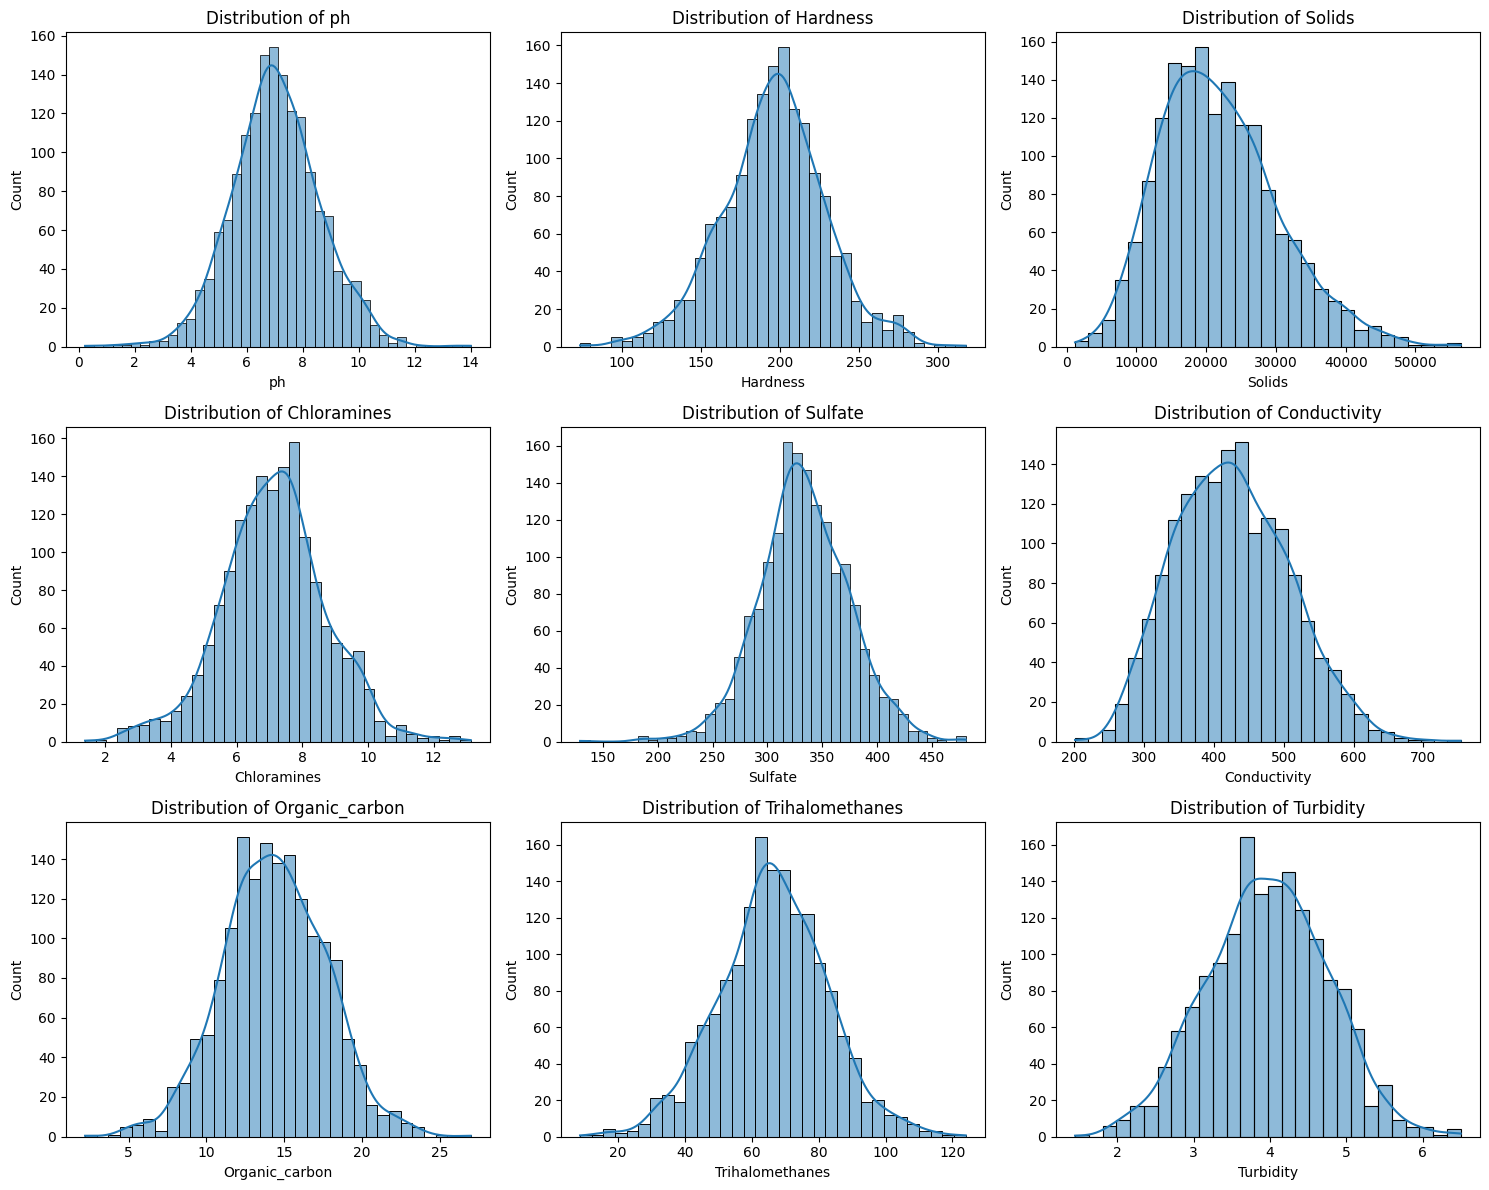

In [12]:
# Set up the figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Plot each numeric column (excluding target)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != 'Potability']

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Boxplots by Potability

**Purpose**: Identify which water quality parameters differ most between potable and non-potable samples.

**Key Observations**:
- **pH**: Potable water tends to have slightly higher pH
- **Chloramines**: Non-potable water shows wider variation
- **Turbidity**: Non-potable water has higher turbidity on average
- **Solids**: No clear difference between groups

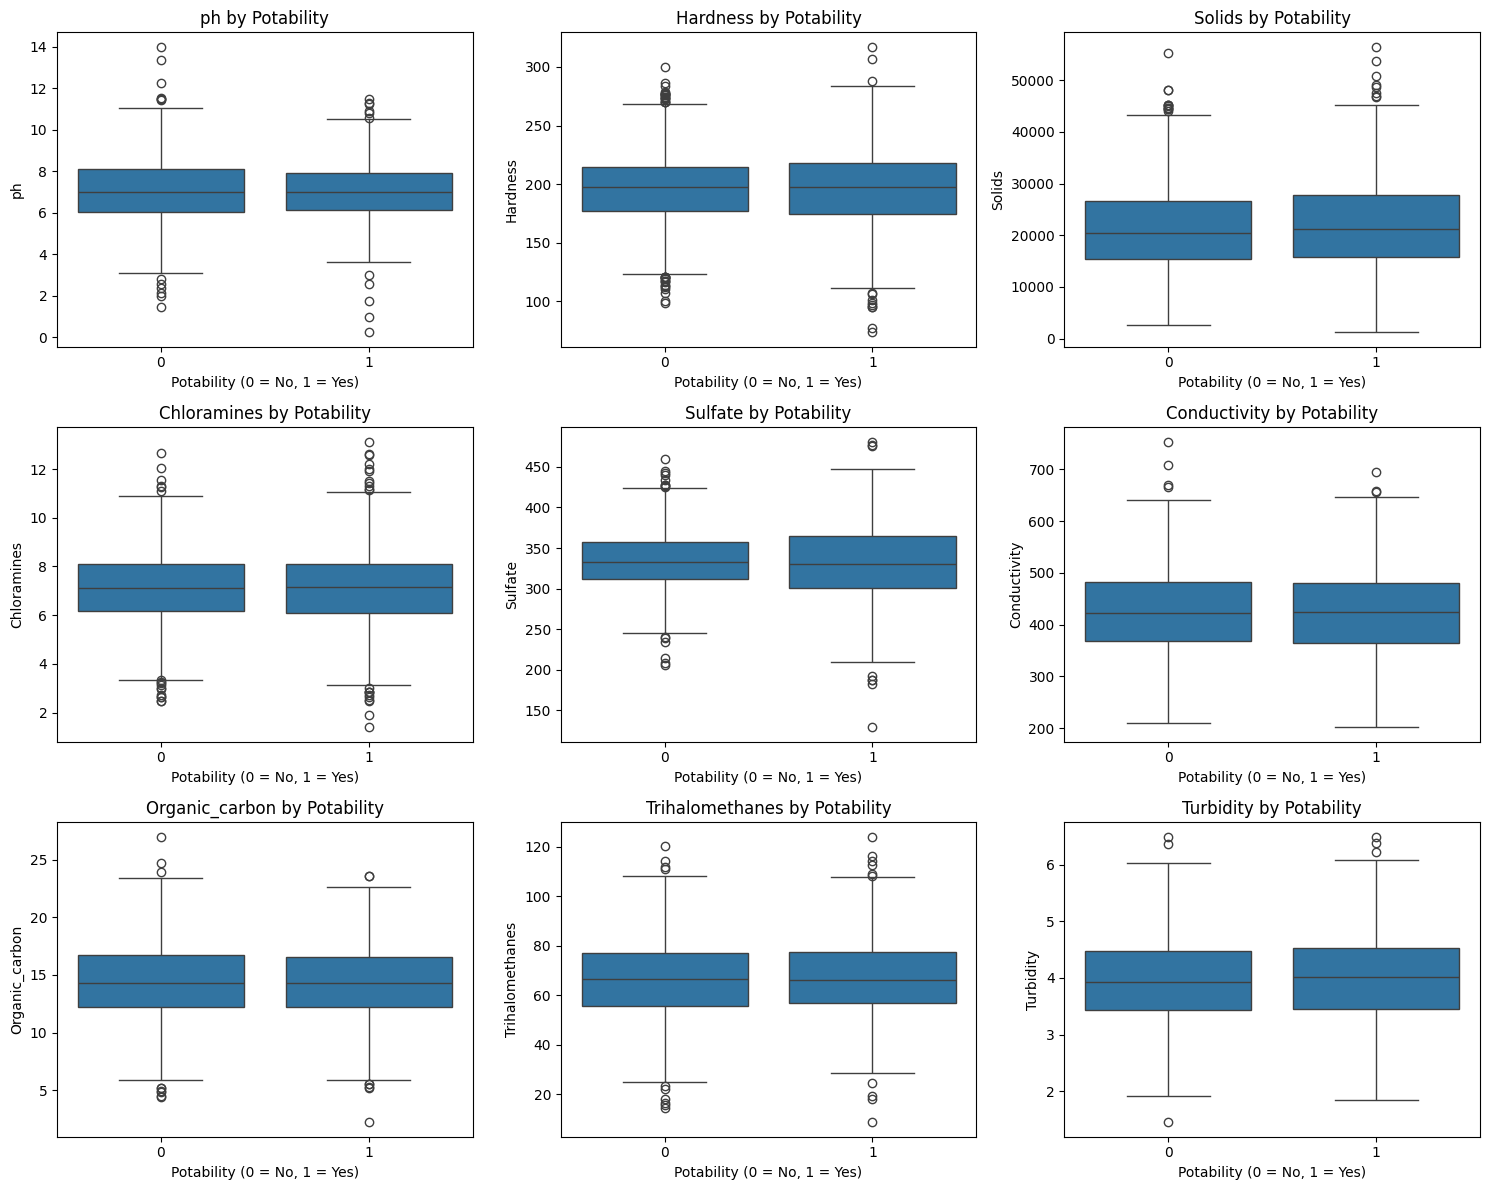

In [13]:
# Set up the figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Plot boxplots for each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Potability', y=col, data=df_clean, ax=axes[i])
    axes[i].set_title(f'{col} by Potability')
    axes[i].set_xlabel('Potability (0 = No, 1 = Yes)')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Potability Breakdown

**Purpose**: Visualize the distribution of potable vs. non-potable water samples.

**Key Observation**: Only ~38% of samples are potable. This imbalance is worth noting for any predictive modeling.

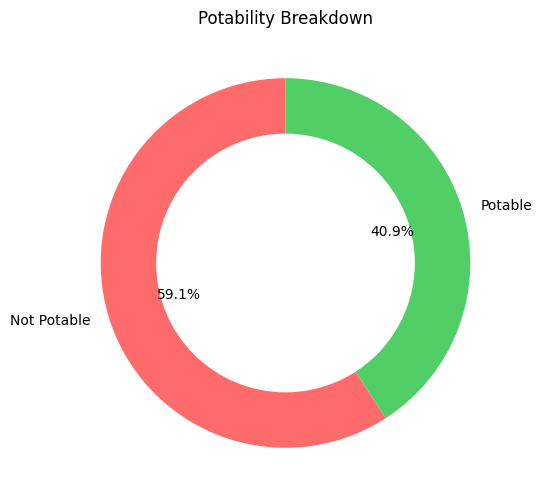

In [15]:
# Count potability values
potability_counts = df_clean['Potability'].value_counts()

# Create donut chart
plt.figure(figsize=(8, 6))
plt.pie(potability_counts, labels=['Not Potable', 'Potable'], autopct='%1.1f%%', 
        startangle=90, colors=['#ff6b6b', '#51cf66'])
plt.title('Potability Breakdown')
plt.gca().add_artist(plt.Circle((0,0), 0.7, fc='white'))
plt.show()